# An ML technique that aggregates two or more learners in order to produce better predictions
## Bagging - Uses modified replicates of a given training data set to train multiple base learners, gen. with the same training algorithm
## Boosting - Each models sequentially tries to correct mistakes of the previos ones

# Random Forest -> Bagging Ensemble learning method on Decision Trees

1. Data Sampling
    1. Row sampling -> Bootstrap sampling with replacement
    2. Column sampling -> We can select the number of features in Random forest -> Feature Sampling or Feature Bagging

# Random Forest can be used for both regression and classificatoin problems

# Out of Bag - it's a built-in validation method in bagging that lets us estimate model performance without a separate validation set.
1. Out of bag samples can be used for validation of the model when it is being trained

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [4]:
titanic = sns.load_dataset("titanic")

features=["pclass","sex","fare","embarked","age"]
target=["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic["age"] = imp_median.fit_transform(titanic[["age"]])

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_frequent = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_frequent.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic[target]

#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)





In [5]:
# Decision Tree Classifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.flatten()

print("training accuracy:", accuracy_score(y_train, model.predict(X_train)))
print("testing accuracy:", accuracy_score(y_test, y_pred_test))

training accuracy: 0.9791332263242376
testing accuracy: 0.7611940298507462


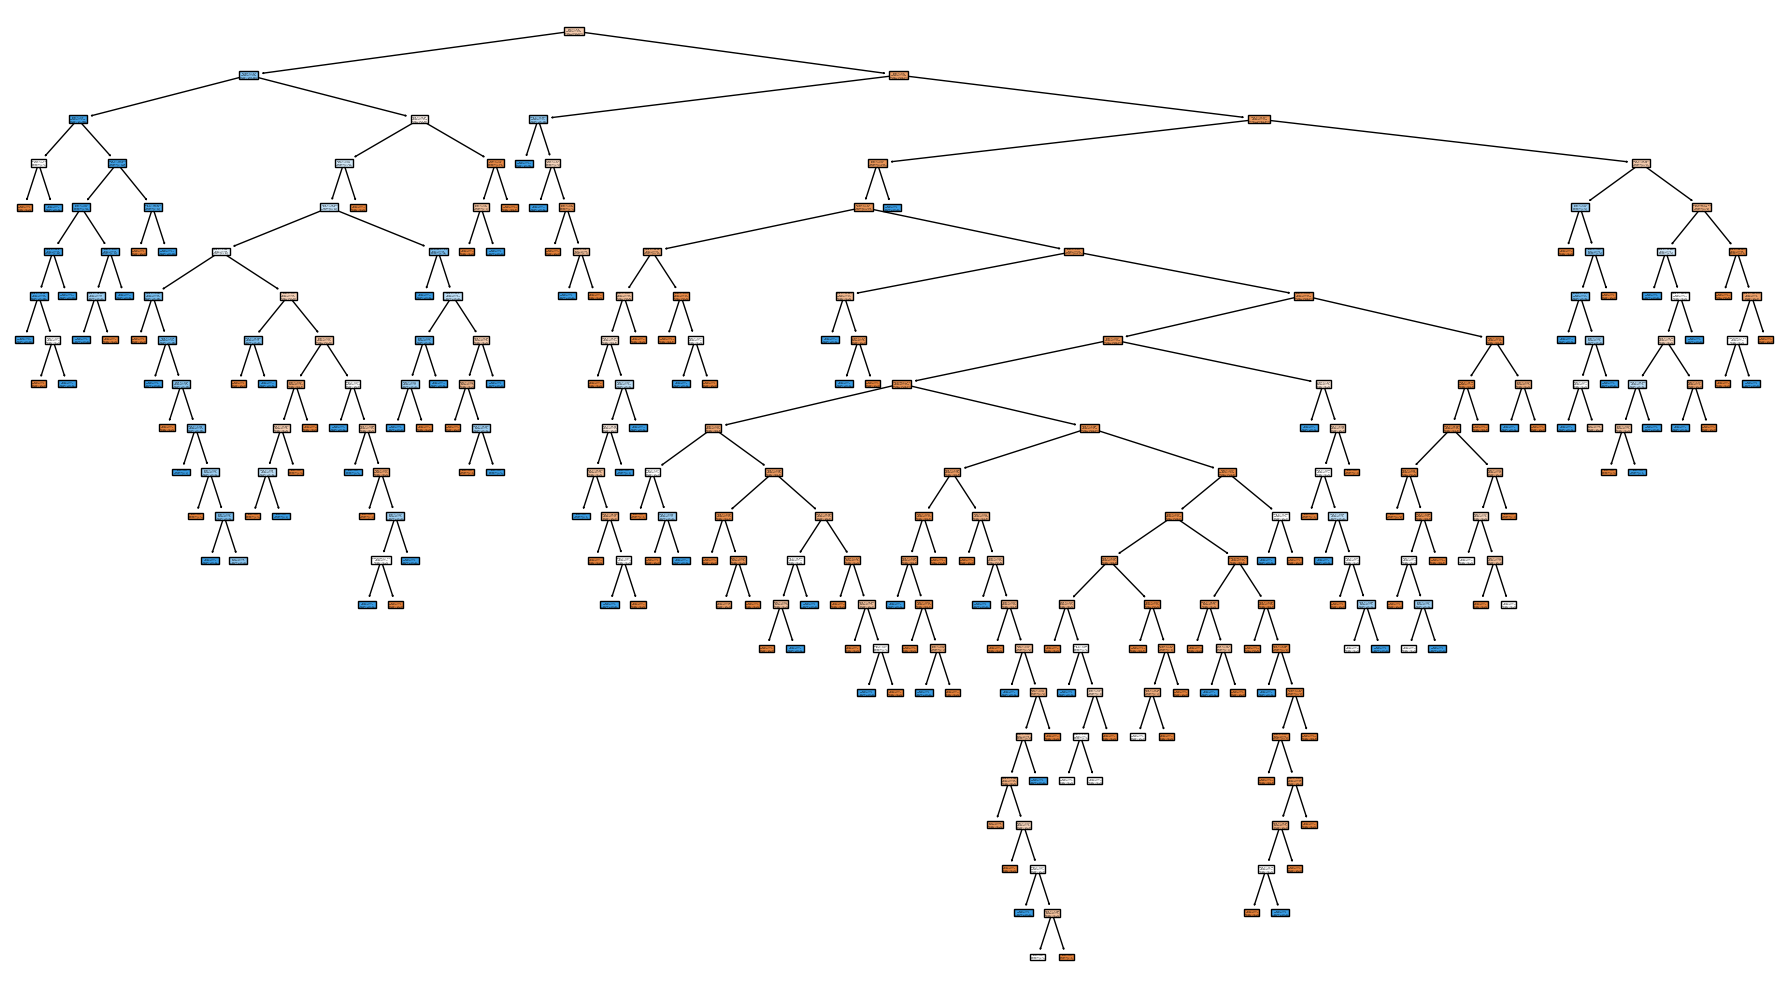

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(model,
    feature_names=X.columns, 
    class_names=["Died", "Survived"], 
    filled=True)
plt.tight_layout()

In [7]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=201, 
                            oob_score=False)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("training accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("testing accuracy:", accuracy_score(y_test, y_pred))



C:\Users\z0050r0z\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


training accuracy: 0.9791332263242376
testing accuracy: 0.7835820895522388
